/var/folders/65/1g3d5l0s4c1dmhh4lc5np1lm0000gn/T/ipykernel_12273/1762210997.py:185: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(aviones))


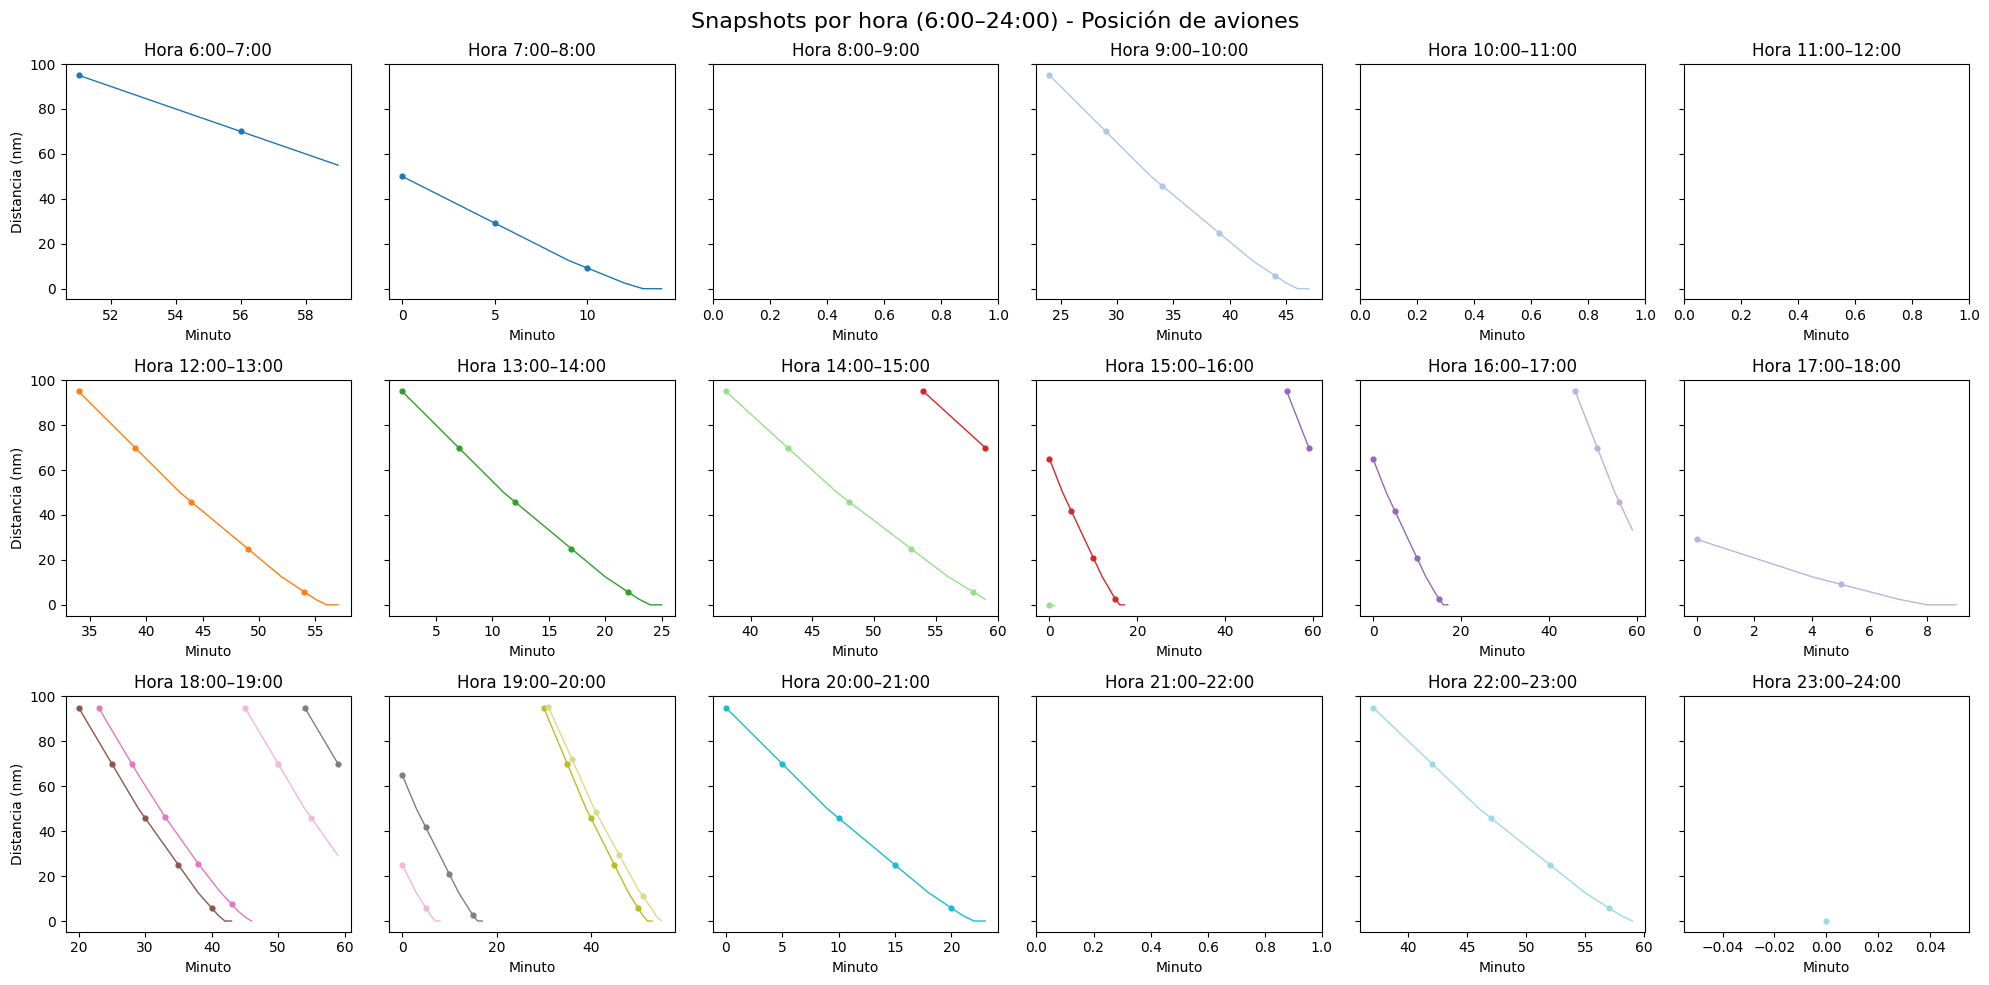

Tiempos de aterrizaje: [74, 227, 417, 445, 541, 557, 617, 669, 763, 767.0, 788, 797, 833, 837.0, 863, 1020]
Separaciones entre aterrizajes: [153, 190, 28, 96, 16, 60, 52, 94, 4.0, 21.0, 9, 36, 4.0, 26.0, 157]
✅ Todas las separaciones cumplen el mínimo de 4 minutos


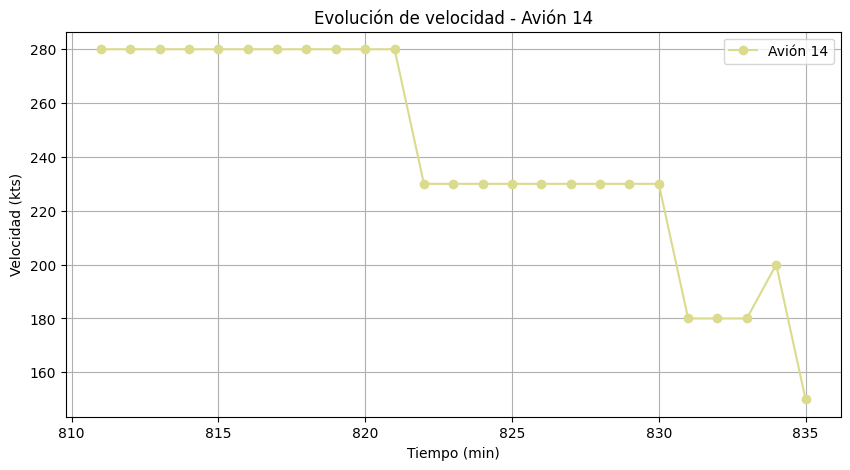

--- Debug de trayectoria: Avión 1 ---
t=  51 min | distancia= 95.00 nm | vel=300.00 kts | estado=acercandose
t=  52 min | distancia= 90.00 nm | vel=300.00 kts | estado=acercandose
t=  53 min | distancia= 85.00 nm | vel=300.00 kts | estado=acercandose
t=  54 min | distancia= 80.00 nm | vel=300.00 kts | estado=acercandose
t=  55 min | distancia= 75.00 nm | vel=300.00 kts | estado=acercandose
t=  56 min | distancia= 70.00 nm | vel=300.00 kts | estado=acercandose
t=  57 min | distancia= 65.00 nm | vel=300.00 kts | estado=acercandose
t=  58 min | distancia= 60.00 nm | vel=300.00 kts | estado=acercandose
t=  59 min | distancia= 55.00 nm | vel=300.00 kts | estado=acercandose
t=  60 min | distancia= 50.00 nm | vel=300.00 kts | estado=acercandose
t=  61 min | distancia= 45.83 nm | vel=250.00 kts | estado=acercandose
t=  62 min | distancia= 41.67 nm | vel=250.00 kts | estado=acercandose
t=  63 min | distancia= 37.50 nm | vel=250.00 kts | estado=acercandose
t=  64 min | distancia= 33.33 nm | vel=

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Dict

# =========================
# Configuración reproducible
# =========================
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# =========================
# Parámetros del problema
# =========================
MIN_ESPACIO = 4.0           # separación mínima en minutos
ESPACIO_OBJETIVO = 5.0      # separación objetivo (usado en incisos posteriores)
RADAR_NM = 100.0            # distancia a la que entran en radar (mn)
VELOCIDAD_DE_RETROCESO_KTS = 200.0
NUDOS_A_MNxMIN = 1.0 / 60.0  # conversión nudos -> mn/min


def rango_de_velocidad_permitido(distancia_a_mn: float) -> Tuple[float, float]:
    """Devuelve (min_kts, max_kts) permitidos según la tabla del enunciado."""
    if distancia_a_mn > 100.0:
        return 300.0, 500.0
    elif distancia_a_mn > 50.0:
        return 250.0, 300.0   # 100..50
    elif distancia_a_mn > 15.0:
        return 200.0, 250.0   # 50..15
    elif distancia_a_mn > 5.0:
        return 150.0, 200.0   # 15..5
    else:
        return 120.0, 150.0   # 5..0




# =========================
# Clase Avion
# =========================
@dataclass
class Avion:
    avion_id: int
    tiempo_de_aparicion: int
    distancia_a_mn: float = RADAR_NM
    velocidad_kts: float = 0.0
    estado: str = "acercandose"  # acercandose | retrocediendo | desviado | aterrizado
    tiempo_de_aterrizaje: Optional[int] = None
    tiempo_de_desvio: Optional[int] = None
    historial_de_tiempos: List[int] = field(default_factory=list)
    historial_de_distancias: List[float] = field(default_factory=list)
    historial_de_velocidades: List[float] = field(default_factory=list)
    historial_de_estados: List[str] = field(default_factory=list)



    def registrar(self, t: int):
        """Guarda el tiempo y distancia actual en la trayectoria."""
        self.historial_de_tiempos.append(t)
        self.historial_de_distancias.append(self.distancia_a_mn)
        self.historial_de_velocidades.append(self.velocidad_kts)
        self.historial_de_estados.append(self.estado)




    # Compatibilidad con graficar_snapshots
    @property
    def trayectoria(self) -> List[Tuple[int, float]]:
        return list(zip(self.historial_de_tiempos, self.historial_de_distancias))

    @property
    def id(self):
        return self.avion_id


# =========================
# Clase Aeropuerto AEP
# =========================
class AEP:
    """Simulación de arribos y aproximación a AEP (inciso 1 con separación mínima)."""
    def __init__(self, lam: float, T_minutes: int):
        assert 0.0 < lam <= 1.0, "λ debe estar entre 0 y 1"
        self.lam = lam
        self.T = T_minutes
        self.aviones: List[Avion] = []
        self.next_id = 1
        self.ultimo_aterrizaje = -1  # -1 significa que todavía no aterrizó nadie

    def generar_si_llega(self, t: int):
        """Genera un nuevo avión en el radar si ocurre un arribo en este minuto."""
        if rng.random() < self.lam:
            _, max_kts = rango_de_velocidad_permitido(RADAR_NM)
            avion = Avion(
                avion_id=self.next_id,
                tiempo_de_aparicion=t,
                distancia_a_mn=RADAR_NM,
                velocidad_kts=max_kts,
                estado="acercandose"
            )
            self.aviones.append(avion)
            self.next_id += 1

    def actualizacion_de_posicion(self, t: int):
        """Avanza todos los aviones aplicando separación mínima de 4 min en vuelo y pista."""

        # ordenar por distancia a la pista (más cerca primero)
        aviones_en_vuelo = [a for a in self.aviones if a.estado == "acercandose"]
        aviones_en_vuelo.sort(key=lambda a: a.distancia_a_mn)

        for i, avion in enumerate(aviones_en_vuelo):
            vmin, vmax = rango_de_velocidad_permitido(avion.distancia_a_mn)
            velocidad = vmax  # por defecto máxima

            if i > 0:  # hay un avión adelante
                avion_adelante = aviones_en_vuelo[i-1]

                # tiempos estimados a pista (minutos)
                tiempo_adelante = (avion_adelante.distancia_a_mn /
                                   (avion_adelante.velocidad_kts * NUDOS_A_MNxMIN)) if avion_adelante.velocidad_kts > 0 else float("inf")
                tiempo_actual = (avion.distancia_a_mn /
                                 (vmax * NUDOS_A_MNxMIN)) if vmax > 0 else float("inf")

                separacion = tiempo_actual - tiempo_adelante

                if separacion < MIN_ESPACIO:
                    # baja 20 nudos respecto a vmax
                    velocidad = vmax - 20
                    if velocidad < vmin:
                        # no puede → retrocede
                        avion.estado = "retrocediendo"
                        avion.velocidad_kts = 200
                        avion.distancia_a_mn += avion.velocidad_kts * NUDOS_A_MNxMIN
                        avion.registrar(t)
                        continue
                else:
                    velocidad = vmax

            # avanzar
            avion.velocidad_kts = velocidad
            avion.distancia_a_mn -= avion.velocidad_kts * NUDOS_A_MNxMIN

            # aterrizaje
            if avion.distancia_a_mn <= 0:
                llegada = t
                if self.ultimo_aterrizaje < 0:
                    # primer avión → aterriza directo
                    aterrizaje_real = llegada
                else:
                    aterrizaje_real = max(llegada, self.ultimo_aterrizaje + MIN_ESPACIO)

                avion.distancia_a_mn = 0
                avion.estado = "aterrizado"
                avion.tiempo_de_aterrizaje = aterrizaje_real
                self.ultimo_aterrizaje = aterrizaje_real

            avion.registrar(t)

    def run(self) -> Dict[str, int]:
        """Corre la simulación completa de T minutos."""
        for t in range(self.T):
            self.generar_si_llega(t)
            self.actualizacion_de_posicion(t)
        return {
            "aparecieron": len(self.aviones),
            "aterrizado": sum(1 for a in self.aviones if a.estado == "aterrizado"),
            "sigue_acercandose": sum(1 for a in self.aviones if a.estado == "acercandose"),
            "retrocediendo": sum(1 for a in self.aviones if a.estado == "retrocediendo"),
        }


# =========================
# Simulación y graficado
# =========================
def simular_trayectorias(lambda_hora=0.017, duracion_horas=18, seed=42):
    rng = np.random.default_rng(seed)
    total_min = int(duracion_horas * 60)
    sim = AEP(lam=lambda_hora, T_minutes=total_min)
    sim.run()
    return sim.aviones


def graficar_snapshots(aviones, duracion_horas=18):
    cmap = cm.get_cmap("tab20", len(aviones))
    colores = {avion.id: cmap(i) for i, avion in enumerate(aviones)}

    fig, axes = plt.subplots(3, 6, figsize=(20, 10), sharey=True)
    axes = axes.flatten()

    for h in range(duracion_horas):
        minuto_ini = h * 60
        minuto_fin = (h + 1) * 60
        ax = axes[h]

        for avion in aviones:
            ts, ds = [], []
            limite = avion.tiempo_de_aterrizaje if avion.tiempo_de_aterrizaje is not None else minuto_fin
            for t, d in avion.trayectoria:
                if minuto_ini <= t < minuto_fin and t <= limite:
                    ts.append(t - minuto_ini)
                    ds.append(d)

            if ts:
                color = colores[avion.id]
                # línea continua
                ax.plot(ts, ds, color=color, linewidth=1)
                # puntos cada 5 muestras
                ax.scatter(ts[::5], ds[::5], c=[color], s=12)

        ax.invert_yaxis()
        ax.set_title(f"Hora {6+h}:00–{7+h}:00")
        ax.set_xlabel("Minuto")
        if h % 6 == 0:
            ax.set_ylabel("Distancia (nm)")

    plt.suptitle("Snapshots por hora (6:00–24:00) - Posición de aviones", fontsize=16)
    plt.tight_layout()
    plt.show()

    return colores


# =========================
# Verificación de separaciones
# =========================
def verificar_separaciones(aviones, min_sep=4):
    """Chequea las separaciones entre aterrizajes y reporta si alguna es < min_sep."""
    aterrizajes = sorted(
        [a.tiempo_de_aterrizaje for a in aviones if a.tiempo_de_aterrizaje is not None]
    )
    diffs = [aterrizajes[i] - aterrizajes[i-1] for i in range(1, len(aterrizajes))]

    print("Tiempos de aterrizaje:", aterrizajes)
    print("Separaciones entre aterrizajes:", diffs)

    violaciones = [(aterrizajes[i-1], aterrizajes[i], diffs[i-1])
                   for i in range(1, len(aterrizajes)) if diffs[i-1] < min_sep]

    if violaciones:
        print(f"⚠️ Se encontraron {len(violaciones)} violaciones (< {min_sep} min):")
        for t1, t2, d in violaciones:
            print(f"- Aterrizajes en {t1} y {t2} (solo {d} minutos de diferencia)")
    else:
        print(f"✅ Todas las separaciones cumplen el mínimo de {min_sep} minutos")


def verificar_separacion_en_vuelo(aviones):
    """Chequea minuto a minuto que se cumpla la lógica de separación en vuelo."""
    aviones_en_vuelo = [a for a in aviones if len(a.trayectoria) > 0]

    for i in range(1, len(aviones_en_vuelo)):
        avion = aviones_en_vuelo[i]
        avion_adelante = aviones_en_vuelo[i-1]

        # recorrer minuto a minuto la trayectoria
        for (t1, d1), (t2, d2) in zip(avion.trayectoria, avion_adelante.trayectoria):
            if t1 != t2:
                continue  # sincronizamos tiempos
            # tiempos estimados a pista
            if avion.velocidad_kts > 0:
                tiempo_restante = d1 / (avion.velocidad_kts * NUDOS_A_MNxMIN)
            else:
                tiempo_restante = float("inf")

            if avion_adelante.velocidad_kts > 0:
                tiempo_restante_adelante = d2 / (avion_adelante.velocidad_kts * NUDOS_A_MNxMIN)
            else:
                tiempo_restante_adelante = float("inf")

            separacion = tiempo_restante - tiempo_restante_adelante

            if separacion < MIN_ESPACIO:
                print(f"⚠️ {avion.id} estuvo a {separacion:.2f} min del avión {avion_adelante.id} en t={t1}")
            elif separacion < (MIN_ESPACIO + 1):
                print(f"ℹ️ {avion.id} está en buffer de seguridad (sep={separacion:.2f} min) en t={t1}")

def mostrar_velocidades(aviones, avion_id: int, colores=None):
    """Grafica la velocidad de un avión a lo largo del tiempo usando el color de snapshots."""
    avion = next((a for a in aviones if a.avion_id == avion_id), None)
    if not avion:
        print(f"No se encontró el avión con id {avion_id}")
        return
    
    color = colores[avion_id] if colores and avion_id in colores else "blue"
    
    plt.figure(figsize=(10, 5))
    plt.plot(avion.historial_de_tiempos, avion.historial_de_velocidades, 
             marker="o", color=color, label=f"Avión {avion_id}")
    plt.title(f"Evolución de velocidad - Avión {avion_id}")
    plt.xlabel("Tiempo (min)")
    plt.ylabel("Velocidad (kts)")
    plt.legend()
    plt.grid(True)
    plt.show()

def debug_trayectoria(aviones, avion_id):
    avion = next((a for a in aviones if a.id == avion_id), None)
    if avion is None:
        print(f"No se encontró el avión {avion_id}")
        return
    
    print(f"--- Debug de trayectoria: Avión {avion.id} ---")
    for t, d, v, e in zip(avion.historial_de_tiempos,
                          avion.historial_de_distancias,
                          avion.historial_de_velocidades,
                          avion.historial_de_estados):
        print(f"t={t:4d} min | distancia={d:6.2f} nm | vel={v:6.2f} kts | estado={e}")








# =========================
# Ejemplo de uso
# =========================
if __name__ == "__main__":
    aviones = simular_trayectorias(lambda_hora=0.017, duracion_horas=18)
    colores=graficar_snapshots(aviones, duracion_horas=18)
    verificar_separaciones(aviones, min_sep=4)  #en pista
    verificar_separacion_en_vuelo(aviones)               # en vuelo
    mostrar_velocidades(aviones, avion_id=14, colores = colores)  
    debug_trayectoria(aviones, 1)   
    debug_trayectoria(aviones, 2)  
    debug_trayectoria(aviones, 4)  
    debug_trayectoria(aviones, 5)  
    debug_trayectoria(aviones, 6)  
    debug_trayectoria(aviones, 7)
    debug_trayectoria(aviones, 8)
    debug_trayectoria(aviones, 9)
    debug_trayectoria(aviones, 10)
    debug_trayectoria(aviones, 11)
    debug_trayectoria(aviones, 12)
    debug_trayectoria(aviones, 13)
    debug_trayectoria(aviones, 14)
    debug_trayectoria(aviones, 15)
    debug_trayectoria(aviones, 16)




2) Si el promedio de arribos es de 1 avión por hora, cuánto es λ?

In [69]:
import numpy as np

# =========================
# Parámetros
# =========================
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

lambda_por_minuto = 1/60   # λ = 1/60
horas_simuladas = 10000    # corridas para promediar
minutos_por_hora = 60

# =========================
# Simulación
# =========================
arribos_por_hora = []

for _ in range(horas_simuladas):
    arribos = 0
    for minuto in range(minutos_por_hora):
        if rng.random() < lambda_por_minuto:
            arribos += 1
    arribos_por_hora.append(arribos)

# =========================
# Resultados
# =========================
promedio = np.mean(arribos_por_hora)
print(f"λ usado = {lambda_por_minuto:.5f} → esperado = 1 avión/hora")
print(f"Promedio simulado = {promedio:.4f} aviones/hora en {horas_simuladas} horas")


λ usado = 0.01667 → esperado = 1 avión/hora
Promedio simulado = 0.9962 aviones/hora en 10000 horas
